#### Import required libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Load Dataset

In [3]:
df = pd.read_csv("Palo Alto Networks.csv")

##### The first five records are displayed to undersatnd the structure and type of information available  

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


#### Dataset Shape

In [5]:
df.shape

(1470, 31)

#### Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

##### The dataset contains both numerical and categorical variables.


#### Check Missing Values

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

##### The missing-value check shows that there are no missing values in the important analytical variables.


#### Check Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(0)

##### No duplicate records were identified, so the dataset can be used for further analysis without duplicate removal.

#### Attrition Distribution

In [9]:
attrition_counts = df["Attrition"].value_counts()

attrition_counts

Attrition
0    1233
1     237
Name: count, dtype: int64

In [10]:
attrition_rate = df["Attrition"].mean() * 100

print("Overall Attrition Rate:", round(attrition_rate, 2), "%")

Overall Attrition Rate: 16.12 %


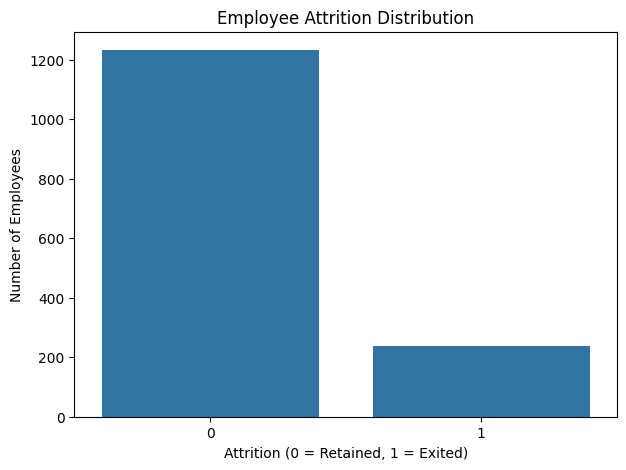

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition (0 = Retained, 1 = Exited)")
plt.ylabel("Number of Employees")

plt.show()

##### The overall attrition rate is approximately **16.12%**.
##### This means that around 16 out of every 100 employees in the dataset have left the organization, while the majority of employees have remained.

#### Department Analysis

In [12]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


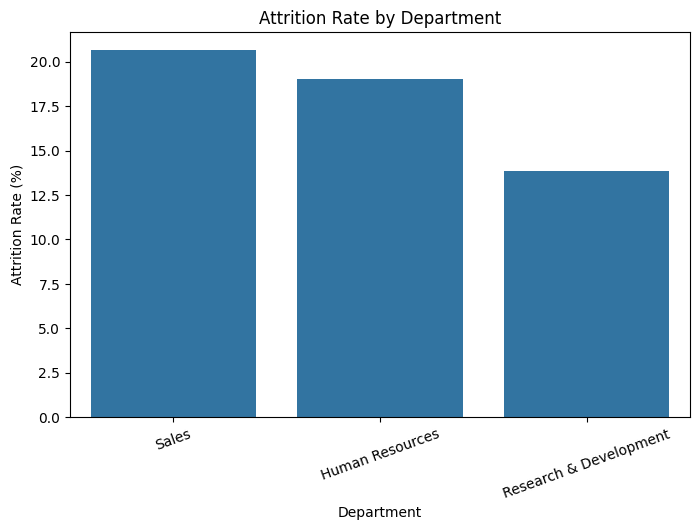

In [13]:
dept_rate = df.groupby("Department")["Attrition"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))

sns.barplot(
    x=dept_rate.index,
    y=dept_rate.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)

plt.show()

##### The department-level analysis shows that **Sales has the highest attrition rate**, followed by Human Resources, while Research & Development has a lower attrition rate. Sales therefore represents an important departmental risk area.

#### Job Role Analysis

In [14]:
role_rate = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

role_rate

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

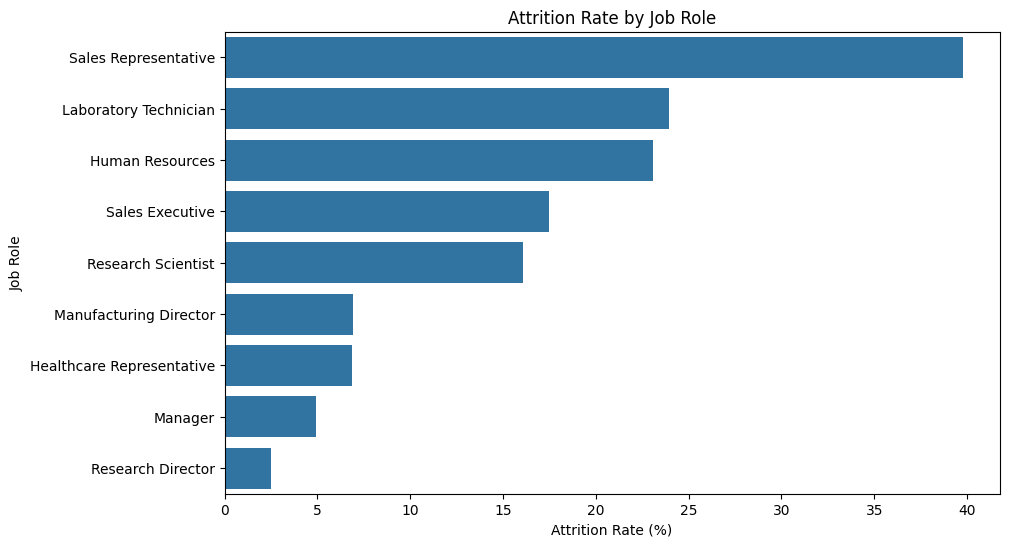

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=role_rate.values,
    y=role_rate.index
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

##### The job-role analysis reveals substantial differences in attrition across different positions. **Sales Representatives have the highest attrition rate**, making this role a major workforce risk hotspot. Laboratory Technicians and Human Resources roles also show comparatively high attrition. In contrast, senior roles such as Research Director and Manager have considerably lower attrition rates. This suggests that attrition is not evenly distributed across job roles and that targeted retention strategies may be more effective than organization-wide measures.

#### Age Group Analysis

In [16]:
bins = [0, 25, 35, 45, 55, 100]

labels = [
    "≤25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [17]:
age_attrition = df.groupby(
    "AgeGroup",
    observed=True
)["Attrition"].mean() * 100

age_attrition

AgeGroup
≤25      35.772358
26-35    19.141914
36-45     9.188034
46-55    11.504425
56+      17.021277
Name: Attrition, dtype: float64

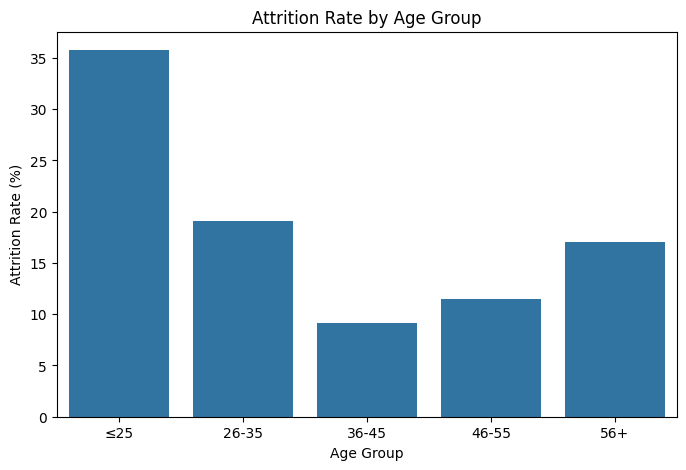

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_attrition.index,
    y=age_attrition.values
)

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")

plt.show()

##### The analysis shows that **employees aged 25 years or below have the highest attrition rate**, at approximately 35.77%. Attrition decreases considerably among employees in the middle-age groups. This indicates that early-career employees represent an important attrition hotspot. Possible organizational factors that should be examined further include career progression, compensation, workload, job satisfaction, and opportunities for professional development.

#### Tenure Analysis

In [19]:
bins = [-1, 1, 3, 5, 10, 100]

labels = [
    "0-1 Years",
    "2-3 Years",
    "4-5 Years",
    "6-10 Years",
    "11+ Years"
]

df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=bins,
    labels=labels
)

In [20]:
tenure_attrition = (
    df.groupby("TenureGroup", observed=True)["Attrition"]
    .mean() * 100
)

tenure_attrition

TenureGroup
0-1 Years     34.883721
2-3 Years     18.431373
4-5 Years     13.071895
6-10 Years    12.276786
11+ Years      8.130081
Name: Attrition, dtype: float64

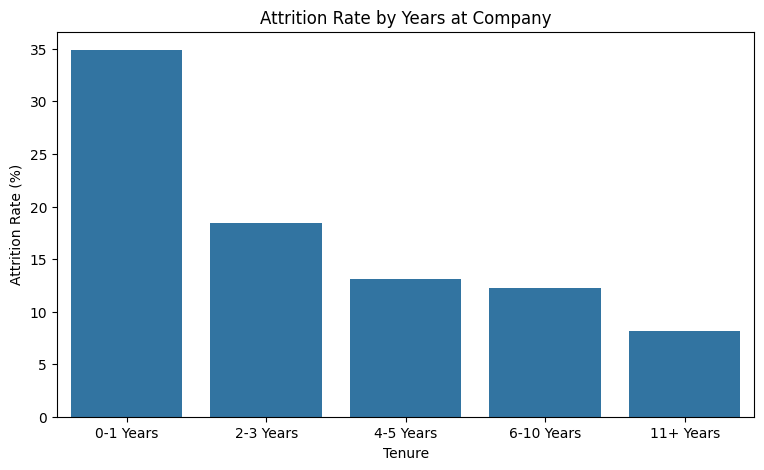

In [21]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=tenure_attrition.index,
    y=tenure_attrition.values
)

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Tenure")
plt.ylabel("Attrition Rate (%)")

plt.show()

##### The tenure analysis shows a clear concentration of attrition among employees with shorter organizational tenure. Employees with **0-1 years at the company have the highest attrition rate, approximately 34.88%**. Attrition generally decreases as employee tenure increases, with employees having 11 or more years at the company showing substantially lower attrition. This indicates that the early employment period is a critical retention stage.

#### Overtime Analysis

In [22]:
overtime_rate = (
    df.groupby("OverTime")["Attrition"]
    .mean() * 100
)

overtime_rate

OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

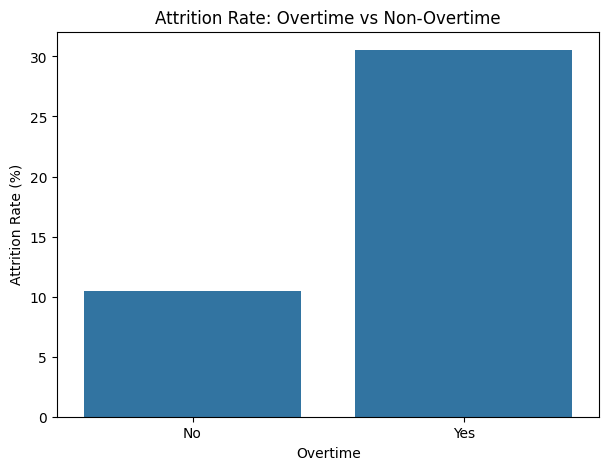

In [23]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=overtime_rate.index,
    y=overtime_rate.values
)

plt.title("Attrition Rate: Overtime vs Non-Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.show()

##### Employees who work overtime have a substantially higher attrition rate than employees who do not work overtime.The attrition rate for employees working overtime is approximately **30.53%**,compared with approximately **10.44%** for employees who do not work overtime.

####  Business Travel Analysis

In [24]:
travel_rate = (
    df.groupby("BusinessTravel")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

travel_rate

BusinessTravel
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Non-Travel            8.000000
Name: Attrition, dtype: float64

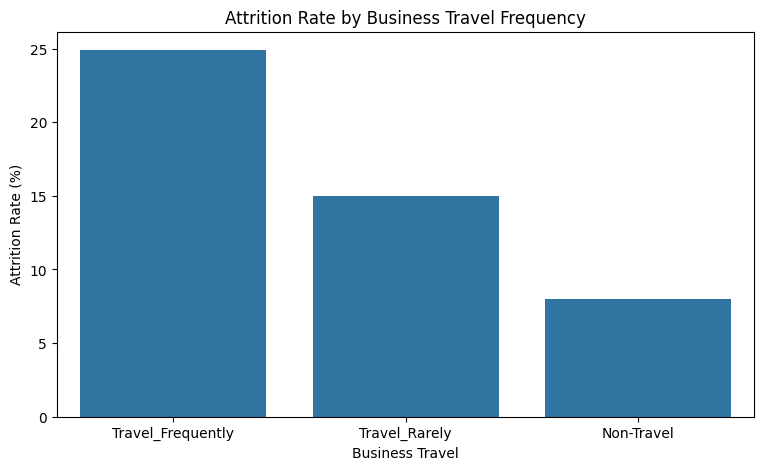

In [25]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=travel_rate.index,
    y=travel_rate.values
)

plt.title("Attrition Rate by Business Travel Frequency")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")

plt.show()

##### Employees who travel frequently show a substantially higher attrition rate than employees who do not travel.Frequent travelers have an attrition rate of approximately **24.91%**, while non-travel employees have an attrition rate of approximately **8%**.This indicates that frequent business travel is associated with higher employee attrition.


#### Distance From Home

In [27]:
bins = [0, 5, 10, 20, 100]

labels = [
    "0-5",
    "6-10",
    "11-20",
    "21+"
]

df["DistanceGroup"] = pd.cut(
    df["DistanceFromHome"],
    bins=bins,
    labels=labels
)

distance_rate = (
    df.groupby("DistanceGroup", observed=True)["Attrition"]
    .mean() * 100
)

distance_rate

DistanceGroup
0-5      13.765823
6-10     14.467005
11-20    20.000000
21+      22.058824
Name: Attrition, dtype: float64

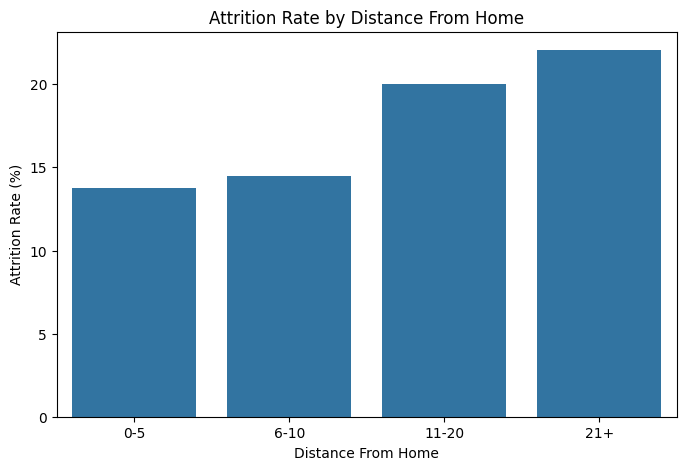

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=distance_rate.index,
    y=distance_rate.values
)

plt.title("Attrition Rate by Distance From Home")
plt.xlabel("Distance From Home")
plt.ylabel("Attrition Rate (%)")

plt.show()

##### Employees living farther from the workplace show higher attrition rates.The highest attrition is observed among employees living 21 or moredistance units from the workplace.This suggests a possible relationship between commuting distance and Employees living farther from the workplace show higher attrition rates.




#### Work-Life Balance

In [29]:
wlb = (
    df.groupby("WorkLifeBalance")["Attrition"]
    .mean() * 100
)

wlb

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

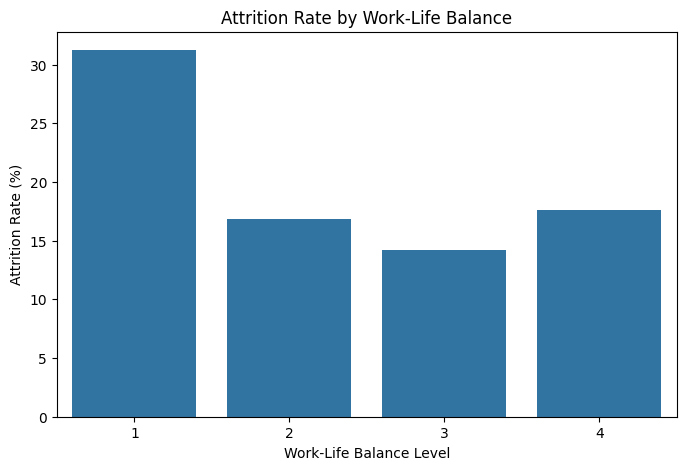

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=wlb.index,
    y=wlb.values
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

##### Employees reporting poor work-life balance have substantially higherattrition than employees reporting better work-life balance.The lowest work-life-balance group has an attrition rate of approximately31.25%. This finding, together with the overtime analysis, indicates that workloadand employee well-being should be important considerations in retentionplanning.

#### Job Satisfaction Analysis 

In [7]:
job_satisfaction_rate = (
    df.groupby("JobSatisfaction")["Attrition"]
    .mean() * 100
)

job_satisfaction_rate

JobSatisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: Attrition, dtype: float64

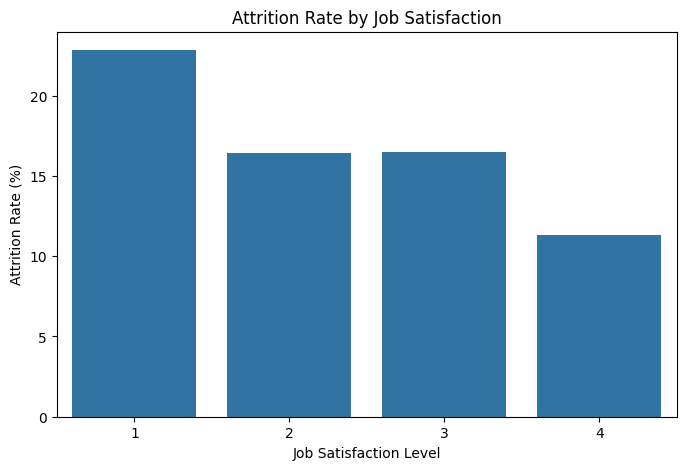

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=job_satisfaction_rate.index,
    y=job_satisfaction_rate.values
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [9]:
for level, rate in job_satisfaction_rate.items():
    print(f"Job Satisfaction Level {level}: {rate:.2f}%")

Job Satisfaction Level 1: 22.84%
Job Satisfaction Level 2: 16.43%
Job Satisfaction Level 3: 16.52%
Job Satisfaction Level 4: 11.33%


#### The analysis compares employee attrition across different job satisfaction levels. The results show how attrition varies among employees with different levels of job satisfaction. This helps identify whether lower or higher satisfaction groups show noticeable differences in employee exits.

#### Environment Satisfaction Analysis

In [10]:
environment_satisfaction_rate = (
    df.groupby("EnvironmentSatisfaction")["Attrition"]
    .mean() * 100
)

environment_satisfaction_rate

EnvironmentSatisfaction
1    25.352113
2    14.982578
3    13.686534
4    13.452915
Name: Attrition, dtype: float64

In [11]:
environment_satisfaction_rate = (
    df.groupby("EnvironmentSatisfaction")["Attrition"]
    .mean() * 100
)

environment_satisfaction_rate

EnvironmentSatisfaction
1    25.352113
2    14.982578
3    13.686534
4    13.452915
Name: Attrition, dtype: float64

In [12]:
for level, rate in environment_satisfaction_rate.items():
    print(f"Environment Satisfaction Level {level}: {rate:.2f}%")
    

Environment Satisfaction Level 1: 25.35%
Environment Satisfaction Level 2: 14.98%
Environment Satisfaction Level 3: 13.69%
Environment Satisfaction Level 4: 13.45%


##### After you run it, use the actual values from your output to describe which satisfaction levels have higher or lower attrition.

#### Years Since Last Promotion

In [13]:
promotion_rate = (
    df.groupby("YearsSinceLastPromotion")["Attrition"]
    .mean() * 100
)

promotion_rate

YearsSinceLastPromotion
0     18.932874
1     13.725490
2     16.981132
3     17.307692
4      8.196721
5      4.444444
6     18.750000
7     21.052632
8      0.000000
9     23.529412
10    16.666667
11     8.333333
12     0.000000
13    20.000000
14    11.111111
15    23.076923
Name: Attrition, dtype: float64

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=promotion_rate.index,
    y=promotion_rate.values
)

plt.title("Attrition Rate by Years Since Last Promotion")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Attrition Rate (%)")

plt.show()


#### Years in Current Role

In [14]:
current_role_rate = (
    df.groupby("YearsInCurrentRole")["Attrition"]
    .mean() * 100
)

current_role_rate

YearsInCurrentRole
0     29.918033
1     19.298246
2     18.279570
3     11.851852
4     14.423077
5      2.777778
6      5.405405
7     13.963964
8      7.865169
9      8.955224
10     6.896552
11     0.000000
12    10.000000
13     7.142857
14     9.090909
15    25.000000
16     0.000000
17     0.000000
18     0.000000
Name: Attrition, dtype: float64

In [15]:
current_role_rate = (
    df.groupby("YearsInCurrentRole")["Attrition"]
    .mean() * 100
)

current_role_rate

YearsInCurrentRole
0     29.918033
1     19.298246
2     18.279570
3     11.851852
4     14.423077
5      2.777778
6      5.405405
7     13.963964
8      7.865169
9      8.955224
10     6.896552
11     0.000000
12    10.000000
13     7.142857
14     9.090909
15    25.000000
16     0.000000
17     0.000000
18     0.000000
Name: Attrition, dtype: float64

#### Years With Current Manager

In [17]:
manager_rate = (
    df.groupby("YearsWithCurrManager")["Attrition"]
    .mean() * 100
)

manager_rate

YearsWithCurrManager
0     32.319392
1     14.473684
2     14.534884
3     13.380282
4     11.224490
5     12.903226
6     13.793103
7     14.351852
8      9.345794
9      9.375000
10    11.111111
11     4.545455
12     0.000000
13     0.000000
14    40.000000
15     0.000000
16     0.000000
17     0.000000
Name: Attrition, dtype: float64

In [18]:
manager_rate = (
    df.groupby("YearsWithCurrManager")["Attrition"]
    .mean() * 100
)

manager_rate

YearsWithCurrManager
0     32.319392
1     14.473684
2     14.534884
3     13.380282
4     11.224490
5     12.903226
6     13.793103
7     14.351852
8      9.345794
9      9.375000
10    11.111111
11     4.545455
12     0.000000
13     0.000000
14    40.000000
15     0.000000
16     0.000000
17     0.000000
Name: Attrition, dtype: float64

#### Job Level

In [19]:
job_level_rate = (
    df.groupby("JobLevel")["Attrition"]
    .mean() * 100
)

job_level_rate

JobLevel
1    26.335175
2     9.737828
3    14.678899
4     4.716981
5     7.246377
Name: Attrition, dtype: float64

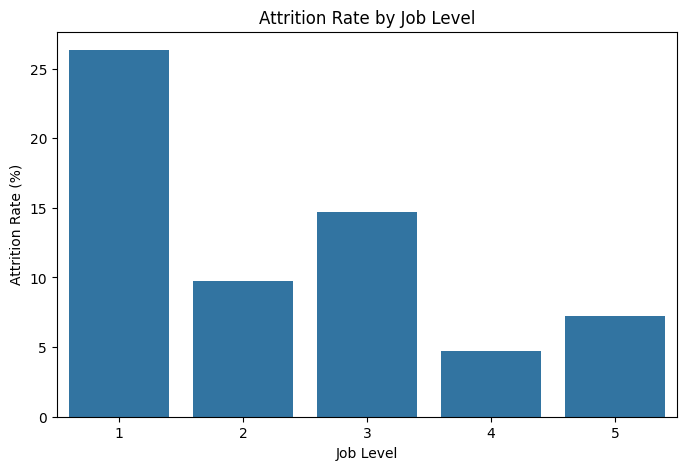

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=job_level_rate.index,
    y=job_level_rate.values
)

plt.title("Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")

plt.show()